# Import Necessery Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

In [45]:
df = pd.read_csv("employee_salary_dataset.csv")
df.head()

,Employee_ID,Department,Job_Level,Gender,Location,Education,Experience_Years,Performance_Rating,Remote_Work,Base_Salary(USD),Bonus_Percentage(%),Bonus_Amount(USD),Total_Compensation(USD)
0,EMP0001,Design,Mid,Male,Seattle,Bachelor,20,4,No,119160,19.0,22640,141800
1,EMP0002,Legal,Manager,Male,Chicago,Bachelor,15,3,No,184083,0.7,1288,185371
2,EMP0003,Engineering,Director,Male,Chicago,PhD,15,4,Yes,237389,16.8,39881,277270
3,EMP0004,Design,Lead,Female,Austin,Bachelor,21,4,No,153230,12.4,19000,172230
4,EMP0005,Marketing,Mid,Male,New York,Bachelor,11,2,Yes,95658,14.3,13679,109337


# Inspect dataframe

In [46]:
print("Shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nTarget stats (Total_Compensation):\n", df['Total_Compensation(USD)'].describe().round(0).astype(int))
print("\nDepartments:", df['Department'].unique())
print("Job Levels:", df['Job_Level'].unique())

Shape: (1000, 13)

Missing values: 0

Target stats (Total_Compensation):
 count      1000
mean     141274
std       45562
min       51505
25%      105524
50%      137044
75%      171974
max      311500
Name: Total_Compensation(USD), dtype: int64

Departments: ['Design' 'Legal' 'Engineering' 'Marketing' 'Finance' 'Operations' 'HR'
 'Sales']
Job Levels: ['Mid' 'Manager' 'Director' 'Lead' 'Senior' 'Junior']


# Choose target & features

In [47]:
# You can also try 'Base_Salary(USD)' if you prefer to predict fixed pay only
target = 'Total_Compensation(USD)'

features = [
    'Department', 'Job_Level', 'Gender', 'Location', 'Education',
    'Experience_Years', 'Performance_Rating', 'Remote_Work',
    'Base_Salary(USD)'     # ← very strong predictor (often kept for realism)
    # 'Bonus_Percentage(%)'  # optional - can cause leakage if predicting total comp
]

X = df[features].copy()
y = df[target].copy()

print("Features:", features)
print("Target: ", target)

Features: ['Department', 'Job_Level', 'Gender', 'Location', 'Education', 'Experience_Years', 'Performance_Rating', 'Remote_Work', 'Base_Salary(USD)']
Target:  Total_Compensation(USD)


# Define categorical and numerical columns

In [48]:
categorical_cols = ['Department', 'Job_Level', 'Gender', 'Location', 'Education', 'Remote_Work']
numerical_cols   = ['Experience_Years', 'Performance_Rating', 'Base_Salary(USD)']

print("Categorical features:", categorical_cols)
print("Numerical features:  ", numerical_cols)

Categorical features: ['Department', 'Job_Level', 'Gender', 'Location', 'Education', 'Remote_Work']
Numerical features:   ['Experience_Years', 'Performance_Rating', 'Base_Salary(USD)']


# Create preprocessing + modeling pipeline

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',  StandardScaler(), numerical_cols),
        ('cat',  OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    LinearRegression())
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# Train / test split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f" Test: {X_test.shape[0]} rows")

Train: 750 rows
 Test: 250 rows


# Fit the model

In [51]:
model.fit(X_train, y_train)
print("Model trained ✓")

Model trained ✓


# Evaluate performance

In [52]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Linear Regression – Employee Total Compensation")
print("──────────────────────────────────────────────")
print(f"MAE:  {mae:,.0f} USD")
print(f"RMSE: {rmse:,.0f} USD")
print(f"R²:   {r2:.3f}  ({r2*100:.1f}%)")

Linear Regression – Employee Total Compensation
──────────────────────────────────────────────
MAE:  8,172 USD
RMSE: 9,847 USD
R²:   0.952  (95.2%)


# Show coefficients (feature importance)

In [53]:
# Extract feature names after encoding
num_features = numerical_cols
cat_features = list(model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(categorical_cols))

all_features = num_features + cat_features

coefs = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefs.round(2)
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.style.format({'Coefficient': '{:.2f}'})

,Feature,Coefficient
2,Base_Salary(USD),45535.71
6,Department_Legal,-3834.94
4,Department_Finance,-3259.90
3,Department_Engineering,-2569.83
7,Department_Marketing,-2159.51
13,Job_Level_Mid,1597.25
16,Gender_Non-binary,-1522.90
24,Education_PhD,-1379.95
14,Job_Level_Senior,1261.74
9,Department_Sales,-1155.40


# Actual vs Predicted scatter plot

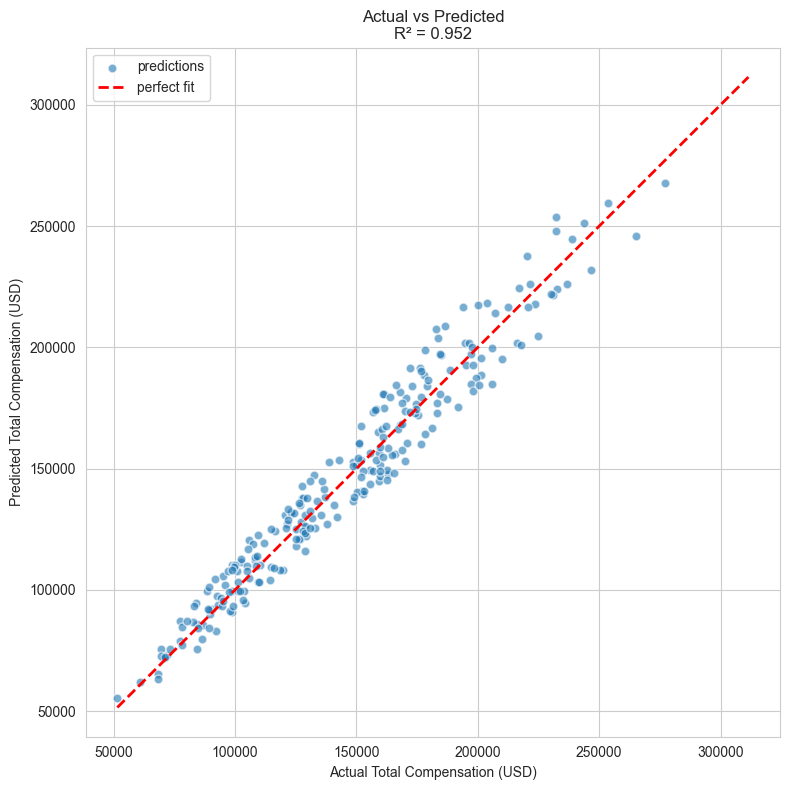

In [54]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6, s=40, edgecolor='white', label='predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='perfect fit')

plt.xlabel('Actual Total Compensation (USD)')
plt.ylabel('Predicted Total Compensation (USD)')
plt.title(f'Actual vs Predicted\nR² = {r2:.3f}')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# Example prediction (new employee)

In [55]:
new_employee = pd.DataFrame({
    'Department':         ['Engineering'],
    'Job_Level':          ['Senior'],
    'Gender':             ['Male'],
    'Location':           ['Seattle'],
    'Education':          ['Master'],
    'Experience_Years':   [12],
    'Performance_Rating': [4],
    'Remote_Work':        ['Yes'],
    'Base_Salary(USD)':   [145000]
})

predicted_comp = model.predict(new_employee)[0]

print(f"Estimated total compensation: ${predicted_comp:,.0f}")

Estimated total compensation: $165,161
